In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
df = pd.read_csv('Lab4_groceries.csv')
df.head()

,Date,ToothPaste,PeanutButter,Biscuits
0,06JAN2008,224,462,381
1,13JAN2008,235,488,398
2,20JAN2008,226,431,349
3,27JAN2008,226,495,397
4,03FEB2008,222,439,367


In [8]:
# Prepare the data for Apriori algorithm
# Convert to binary format (1 if item was purchased, 0 otherwise)
# Set a threshold to consider an item as purchased
threshold = df[['ToothPaste', 'PeanutButter', 'Biscuits']].mean().mean()
print(f"Threshold for binary conversion: {threshold:.2f}")

# Create binary dataset
basket = df[['ToothPaste', 'PeanutButter', 'Biscuits']].applymap(lambda x: 1 if x > threshold else 0)
basket.head()

Threshold for binary conversion: 349.80


/var/folders/vk/9__gtf315yz9cd0rvyyy0mg00000gn/T/ipykernel_64782/2879584328.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = df[['ToothPaste', 'PeanutButter', 'Biscuits']].applymap(lambda x: 1 if x > threshold else 0)


,ToothPaste,PeanutButter,Biscuits
0,0,1,1
1,0,1,1
2,0,1,0
3,0,1,1
4,0,1,1


In [15]:
# Import Apriori and association rules from mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

# Apply Apriori algorithm with minimum support of 0.3
min_support = 0.3
frequent_itemsets = apriori(basket, min_support=min_support, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"\nFrequent Itemsets (min_support={min_support}):")
print(frequent_itemsets)


Frequent Itemsets (min_support=0.3):
    support                  itemsets  length
0  1.000000            (PeanutButter)       1
1  0.961538                (Biscuits)       1
2  0.961538  (PeanutButter, Biscuits)       2


/opt/anaconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [16]:
# Generate association rules with minimum confidence
min_confidence = 0.5
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Display the rules with important metrics: support, confidence, and lift
print(f"\nAssociation Rules (min_confidence={min_confidence}):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].to_string())


Association Rules (min_confidence=0.5):
      antecedents     consequents   support  confidence  lift
0  (PeanutButter)      (Biscuits)  0.961538    0.961538   1.0
1      (Biscuits)  (PeanutButter)  0.961538    1.000000   1.0


/opt/anaconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [17]:
# Interpretation of the rules
print("\n=== INTERPRETATION OF ASSOCIATION RULES ===\n")

for idx, rule in rules.iterrows():
    antecedent = ', '.join(list(rule['antecedents']))
    consequent = ', '.join(list(rule['consequents']))
    
    print(f"Rule {idx + 1}: {antecedent} → {consequent}")
    print(f"  Support: {rule['support']:.3f} - This rule appears in {rule['support']*100:.1f}% of all transactions")
    print(f"  Confidence: {rule['confidence']:.3f} - When {antecedent} is purchased, {consequent} is purchased {rule['confidence']*100:.1f}% of the time")
    print(f"  Lift: {rule['lift']:.3f} - ", end="")
    
    if rule['lift'] > 1:
        print(f"Purchasing {antecedent} increases the likelihood of purchasing {consequent} by {(rule['lift']-1)*100:.1f}%")
    elif rule['lift'] < 1:
        print(f"Purchasing {antecedent} decreases the likelihood of purchasing {consequent}")
    else:
        print(f"Purchasing {antecedent} has no effect on purchasing {consequent}")
    print()


=== INTERPRETATION OF ASSOCIATION RULES ===

Rule 1: PeanutButter → Biscuits
  Support: 0.962 - This rule appears in 96.2% of all transactions
  Confidence: 0.962 - When PeanutButter is purchased, Biscuits is purchased 96.2% of the time
  Lift: 1.000 - Purchasing PeanutButter has no effect on purchasing Biscuits

Rule 2: Biscuits → PeanutButter
  Support: 0.962 - This rule appears in 96.2% of all transactions
  Confidence: 1.000 - When Biscuits is purchased, PeanutButter is purchased 100.0% of the time
  Lift: 1.000 - Purchasing Biscuits has no effect on purchasing PeanutButter



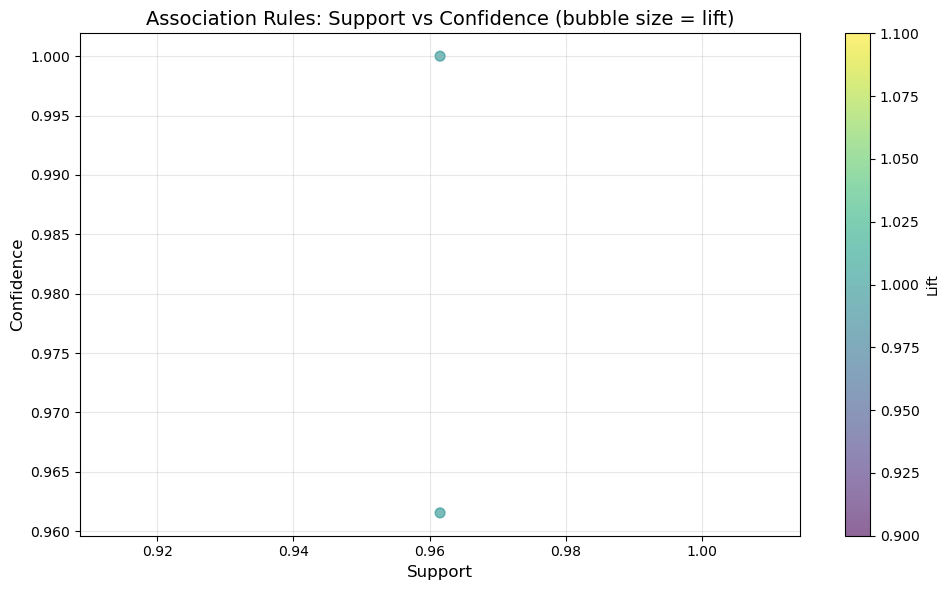

In [18]:
# Visualize Support vs Confidence
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], s=rules['lift']*50, alpha=0.6, c=rules['lift'], cmap='viridis')
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules: Support vs Confidence (bubble size = lift)', fontsize=14)
plt.colorbar(label='Lift')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

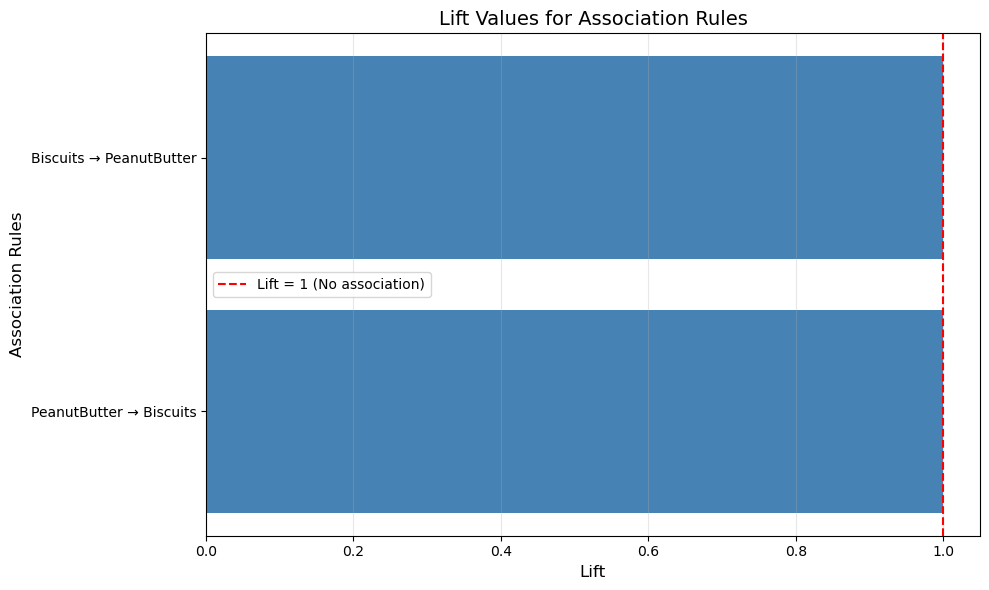

In [19]:
# Visualize Lift values for each rule
plt.figure(figsize=(10, 6))
rule_labels = [f"{', '.join(list(rules.iloc[i]['antecedents']))} → {', '.join(list(rules.iloc[i]['consequents']))}" 
               for i in range(len(rules))]
plt.barh(rule_labels, rules['lift'], color='steelblue')
plt.xlabel('Lift', fontsize=12)
plt.ylabel('Association Rules', fontsize=12)
plt.title('Lift Values for Association Rules', fontsize=14)
plt.axvline(x=1, color='red', linestyle='--', label='Lift = 1 (No association)')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

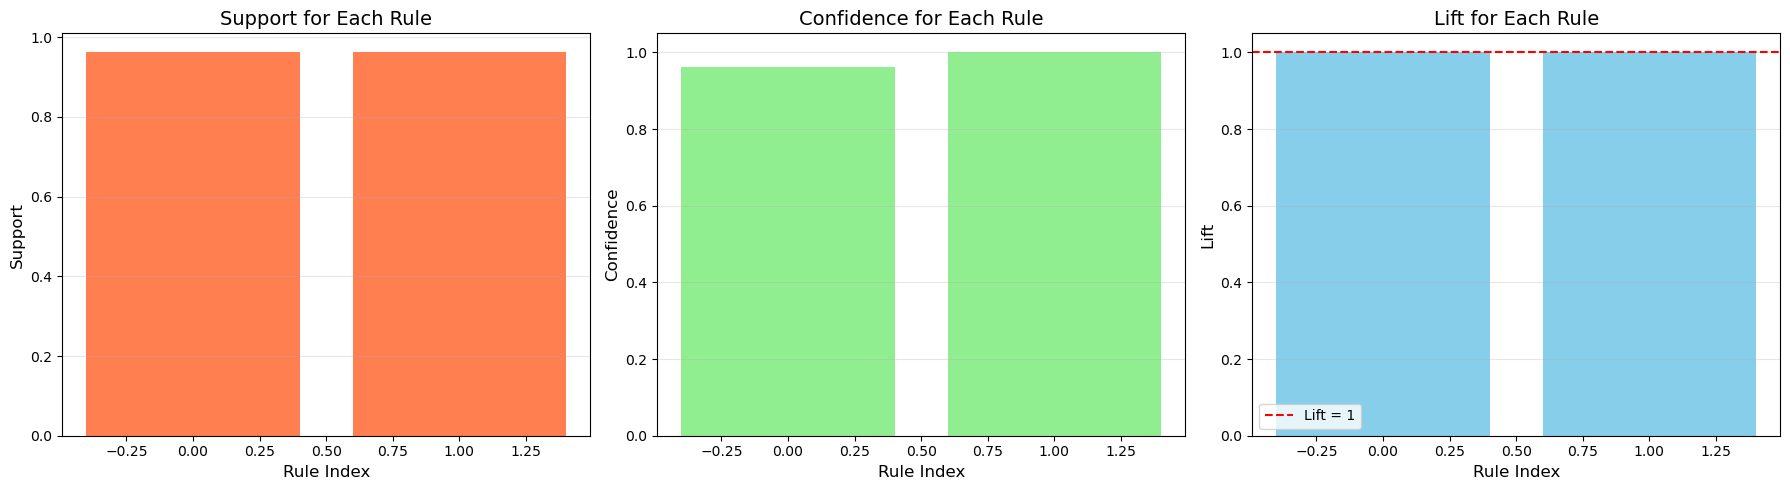

In [20]:
# Visualize Support, Confidence, and Lift comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Support
axes[0].bar(range(len(rules)), rules['support'], color='coral')
axes[0].set_xlabel('Rule Index', fontsize=12)
axes[0].set_ylabel('Support', fontsize=12)
axes[0].set_title('Support for Each Rule', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')

# Confidence
axes[1].bar(range(len(rules)), rules['confidence'], color='lightgreen')
axes[1].set_xlabel('Rule Index', fontsize=12)
axes[1].set_ylabel('Confidence', fontsize=12)
axes[1].set_title('Confidence for Each Rule', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

# Lift
axes[2].bar(range(len(rules)), rules['lift'], color='skyblue')
axes[2].set_xlabel('Rule Index', fontsize=12)
axes[2].set_ylabel('Lift', fontsize=12)
axes[2].set_title('Lift for Each Rule', fontsize=14)
axes[2].axhline(y=1, color='red', linestyle='--', label='Lift = 1')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()